In [1]:
!pip install langgraph langchain_groq langchain_core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.6 MB/s eta 0:00:00


In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
import os

In [3]:
os.environ["GROQ_API_KEY"]=""

In [4]:
class chatstate(TypedDict):
  messages : Annotated[list[str], add_messages]

In [6]:
LLM = ChatGroq(model = "openai/gpt-oss-120b", temperature=0.7)

In [21]:
def chat_node(state: chatstate):
  # we will take the query from state
  Chatmessages = state['messages']

  # we will give this to llm
  response = LLM.invoke(Chatmessages)

  # returning the response
  return {'messages': response}

In [24]:
graph = StateGraph(chatstate)

# graph nodes
graph.add_node("chat_node", chat_node)
# graph edges
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile()

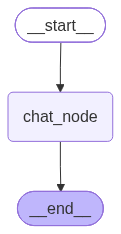

In [18]:
chatbot

In [25]:
initial_state = {
    'messages': [HumanMessage(content = "what is the capitol of spain?")]
}

final_state = chatbot.invoke(initial_state)

In [28]:
print(final_state)
print(final_state['messages'][-1].content)

{'messages': [HumanMessage(content='what is the capitol of spain?', additional_kwargs={}, response_metadata={}, id='9f4d61ce-361d-4fe2-b275-fdadbbe02383'), AIMessage(content='The capital of Spain is **Madrid**.', additional_kwargs={'reasoning_content': 'The user asks: "what is the capitol of spain?" The correct answer: Madrid is the capital. Note spelling: capital. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 80, 'total_tokens': 130, 'completion_time': 0.104273636, 'completion_tokens_details': {'reasoning_tokens': 32}, 'prompt_time': 0.002969029, 'prompt_tokens_details': None, 'queue_time': 0.032975649, 'total_time': 0.107242665}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_dd854ee2d7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f98c9-1fa3-73b3-9c24-44ab69e106e6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 80, 'output_

# lets make it into a normal chatbot

In [29]:
while True:
  user_message = input("type_here: ")

  print("user: ", user_message)

  if user_message.strip().lower() in ['close', 'exit', 'bye']:
    break

  response = chatbot.invoke({'messages': [HumanMessage(content = user_message)]})
  print("AI: ", response['messages'][-1].content)

type_here: hi
user:  hi
AI:  Hello! How can I assist you today?
type_here: im great can yu tell me 2 lines about temple hepsetphu in egypt
user:  im great can yu tell me 2 lines about temple hepsetphu in egypt
AI:  The Temple of Hatshepsut at Deir el‑Bahari, built on a limestone cliff near Luxor, is a stunning terraced mortuary complex dedicated to the female pharaoh Hatshepsut (c. 1479–1458 BC). Its colonnaded terraces and reliefs celebrate her divine birth and famous expedition to the Land of Punt.
type_here: ok thanks
user:  ok thanks
AI:  You’re welcome! If you have any more questions or need further assistance, just let me know.
type_here: bye
user:  bye
